
## Clase Modelos lineales para regresión 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [4]:
data = pd.read_csv('2023-03-08 Precios Casas RM.csv')
data.head()

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213,NaN
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades


<Axes: xlabel='Dorms', ylabel='Price_UF'>

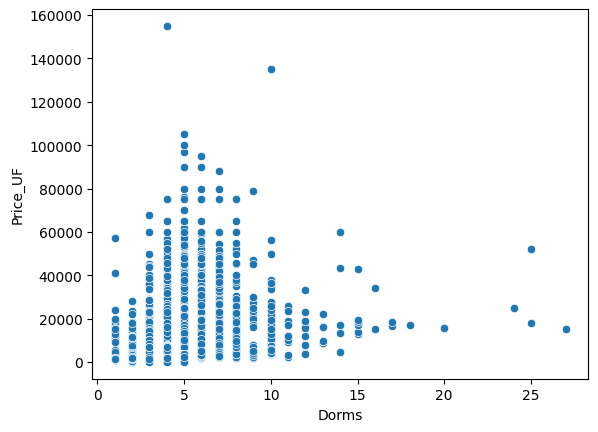

In [5]:
sns.scatterplot(x = data["Dorms"], y = data["Price_UF"])

In [6]:
pd.DataFrame (data.isna().sum())

,0
Price_CLP,0
Price_UF,0
Price_USD,0
Comuna,0
Ubicacion,0
Dorms,0
Baths,65
Built Area,246
Total Area,208
Parking,2290


<Axes: xlabel='Parking', ylabel='Count'>

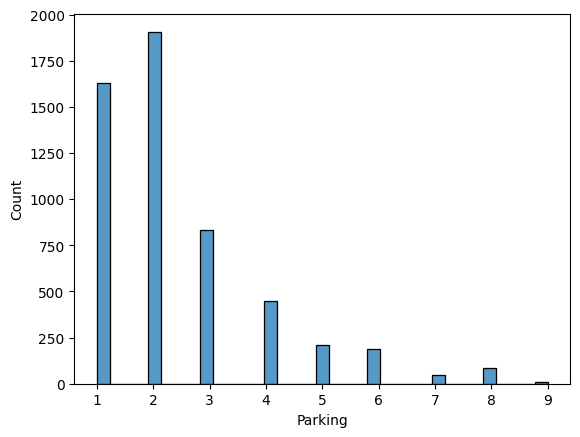

In [7]:
sns.histplot(data[data["Parking"] < 10]["Parking"])

In [8]:
data[data["Total Area"].isna()]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
15,79000000,2220,98381,PuenteAlto,PasajeLagoBertrand,2,1.0,NaN,NaN,2.0,12149041,Fe Propiedades Spa
80,170000000,4777,211706,Conchalí,Nilahue,6,2.0,NaN,NaN,NaN,11608988,Kvs properties
97,139000000,3906,173101,Recoleta,AvenidaMéxico,6,2.0,140.0,NaN,NaN,6716881,Paz Legal & Home
101,80000000,2248,99626,SanBernardo,Villaalameda,4,3.0,NaN,NaN,2.0,11449618,Propital
198,60000000,1686,74720,PuenteAlto,VillaDuraznal,3,1.0,NaN,NaN,1.0,9809866,Evelyn Carrillo Santander
...,...,...,...,...,...,...,...,...,...,...,...,...
7736,140000000,3934,174346,LaFlorida,LasCarmelitas,4,1.0,NaN,NaN,1.0,6943903,Enfoque Propiedades
7737,145000000,4074,180573,PuenteAlto,Pieandino,3,2.0,NaN,NaN,1.0,6791067,Enfoque Propiedades
7742,141000000,3962,175592,LaFlorida,CerroCaracol,3,3.0,NaN,NaN,2.0,7998394,Enfoque Propiedades
7770,249130000,7000,310249,Santiago,Antilhue,3,3.0,NaN,NaN,2.0,6981371,NaN


In [9]:
data = data.drop(columns=["Price_CLP", "Price_USD", "Ubicacion", "id", "Realtor", "Comuna"])
data

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking
0,11500,7,4.0,384.0,732.0,3.0
1,2950,2,1.0,112.0,145.0,1.0
2,3600,3,1.0,59.0,243.0,2.0
3,2107,3,1.0,103.0,73.0,1.0
4,1489,2,1.0,57.0,67.0,1.0
...,...,...,...,...,...,...
7774,70000,5,5.0,600.0,1800.0,5.0
7775,6800,4,2.0,124.0,200.0,1.0
7776,105000,5,7.0,460.0,4925.0,8.0
7777,16000,4,2.0,311.0,2011.0,1.0


In [10]:
from sklearn.impute import KNNImputer

In [11]:
def iqr(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    max_val = q3 + 1.5 * (q3 - q1)
    min_val = q1 - 1.5 * (q3 - q1)
    x = x[(x > min_val) & (x < max_val)]    
    return x
           
for col in data_imputed.columns:
    data_imputed[col] = iqr(data_imputed[col])

In [12]:
data_imputed = data_imputed.dropna()

In [13]:
imputer = KNNImputer(n_neighbors=5)
data_imputed = imputer.fit_transform(data)  
data_imputed = pd.DataFrame(data_imputed, columns=data.columns)
data_imputed

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking
0,11500.0,7.0,4.0,384.0,732.0,3.0
1,2950.0,2.0,1.0,112.0,145.0,1.0
2,3600.0,3.0,1.0,59.0,243.0,2.0
3,2107.0,3.0,1.0,103.0,73.0,1.0
4,1489.0,2.0,1.0,57.0,67.0,1.0
...,...,...,...,...,...,...
7774,70000.0,5.0,5.0,600.0,1800.0,5.0
7775,6800.0,4.0,2.0,124.0,200.0,1.0
7776,105000.0,5.0,7.0,460.0,4925.0,8.0
7777,16000.0,4.0,2.0,311.0,2011.0,1.0


In [14]:
pd.DataFrame (data_imputed.isna().sum())

,0
Price_UF,0
Dorms,0
Baths,0
Built Area,0
Total Area,0
Parking,0


## Construir modelo lineal

In [15]:
#Construir modelo lineal
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn. preprocessing import PolynomialFeatures
#ridge penalizacion cuadratica norma 
#lasso penalizacion lineal en valor asboluto    
#elasticnet penalizacion lineal en valor asboluto y cuadratica combinacion de ambas

In [16]:
X = data_imputed.drop(columns=["Price_UF"])
y = data_imputed["Price_UF"]
X, y

(      Dorms  Baths  Built Area  Total Area  Parking
 0       7.0    4.0       384.0       732.0      3.0
 1       2.0    1.0       112.0       145.0      1.0
 2       3.0    1.0        59.0       243.0      2.0
 3       3.0    1.0       103.0        73.0      1.0
 4       2.0    1.0        57.0        67.0      1.0
 ...     ...    ...         ...         ...      ...
 7774    5.0    5.0       600.0      1800.0      5.0
 7775    4.0    2.0       124.0       200.0      1.0
 7776    5.0    7.0       460.0      4925.0      8.0
 7777    4.0    2.0       311.0      2011.0      1.0
 7778    5.0    3.0       225.0       366.0      2.6
 
 [7779 rows x 5 columns],
 0        11500.0
 1         2950.0
 2         3600.0
 3         2107.0
 4         1489.0
           ...   
 7774     70000.0
 7775      6800.0
 7776    105000.0
 7777     16000.0
 7778      9998.0
 Name: Price_UF, Length: 7779, dtype: float64)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6223, 5), (1556, 5), (6223,), (1556,))

In [18]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression()) 
    
])
pipeline

,steps,"[('scaler', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'


In [19]:
score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="r2") #r2 o varianza explicada   
score 

KeyboardInterrupt: 


Mejores parámetros:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Mejor R2 CV:
0.8845325877961526

RESULTADOS TEST
R2: 0.8871254198574352
RMSE: 0.2575610070304639
MAE: 0.18248596101098732

Cross Validation Scores:
[0.91192076 0.86679613 0.87840488 0.86775121 0.86819867]
Promedio CV: 0.8786143287149855


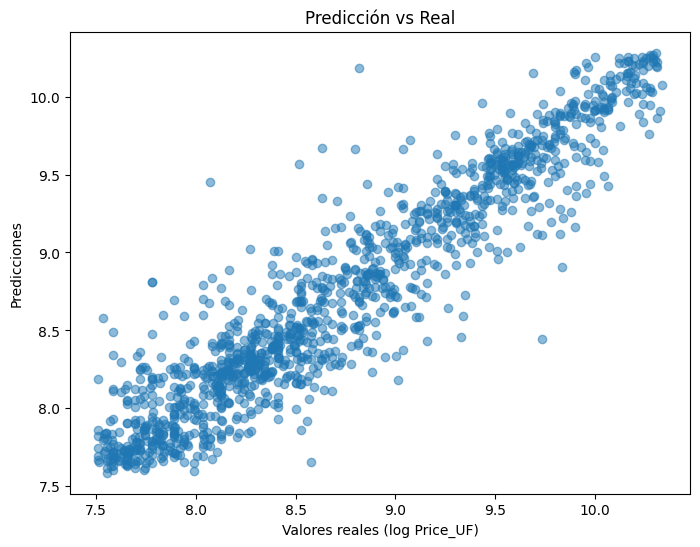

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


data = pd.read_csv("2023-03-08 Precios Casas RM.csv")


data = data.drop(columns=[
    "Price_CLP",
    "Price_USD",
    "Ubicacion",
    "id",
    "Realtor"
])


num_cols = data.select_dtypes(include=np.number).columns

imputer = KNNImputer(n_neighbors=5)
data_num = pd.DataFrame(imputer.fit_transform(data[num_cols]), columns=num_cols)

# recuperar comuna
data_num["Comuna"] = data["Comuna"].values


lower = data_num["Price_UF"].quantile(0.05)
upper = data_num["Price_UF"].quantile(0.95)

data_clean = data_num[
    (data_num["Price_UF"] >= lower) &
    (data_num["Price_UF"] <= upper)
].copy()

# eliminar áreas irreales
data_clean = data_clean[
    (data_clean["Built Area"] < 1000) &
    (data_clean["Total Area"] < 2000)
]


data_clean.loc[:, "Area_ratio"] = data_clean["Built Area"] / data_clean["Total Area"]
data_clean.loc[:, "Rooms"] = data_clean["Dorms"] + data_clean["Baths"]

data_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
data_clean.dropna(inplace=True)


data_clean = pd.get_dummies(data_clean, columns=["Comuna"], drop_first=True)


y = np.log1p(data_clean["Price_UF"])
X = data_clean.drop(columns=["Price_UF"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])


param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nMejores parámetros:")
print(grid.best_params_)

print("\nMejor R2 CV:")
print(grid.best_score_)


best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nRESULTADOS TEST")
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))


scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nCross Validation Scores:")
print(scores)
print("Promedio CV:", scores.mean())


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Valores reales (log Price_UF)")
plt.ylabel("Predicciones")
plt.title("Predicción vs Real")
plt.show()